# GAN 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_swiss_roll
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


Original dataset shape: (2000, 3)
Dataset statistics - Mean: [ 2.04865612 10.41987862  0.01112336], Std: [6.5664444  6.06090515 6.98813149]


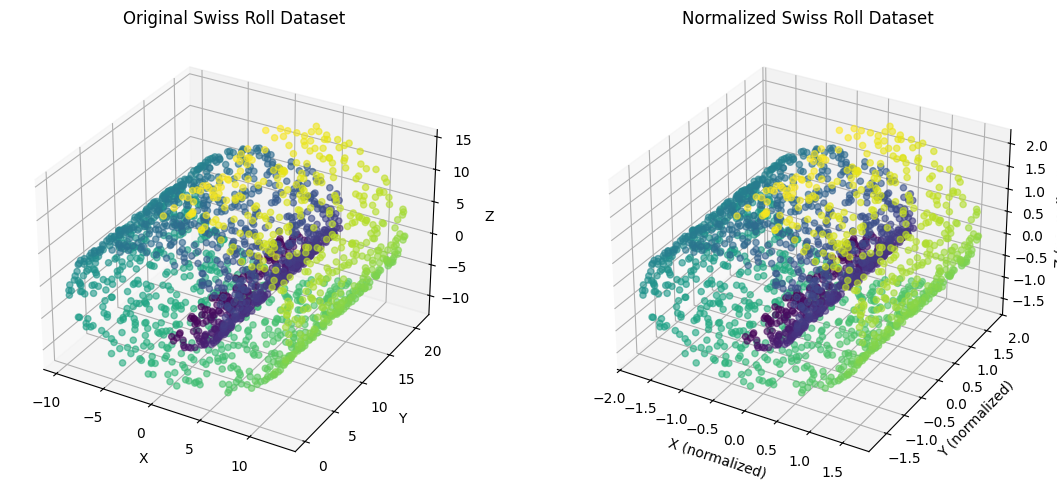

In [3]:
n_samples = 2000
X, t = make_swiss_roll(n_samples=n_samples, noise=0.1, random_state=42)

print(f"Original dataset shape: {X.shape}")
print(f"Dataset statistics - Mean: {X.mean(axis=0)}, Std: {X.std(axis=0)}")

scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap='viridis', alpha=0.6, s=20)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Original Swiss Roll Dataset')

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_normalized[:, 0], X_normalized[:, 1], X_normalized[:, 2], c=t, cmap='viridis', alpha=0.6, s=20)
ax2.set_xlabel('X (normalized)')
ax2.set_ylabel('Y (normalized)')
ax2.set_zlabel('Z (normalized)')
ax2.set_title('Normalized Swiss Roll Dataset')

plt.tight_layout()
plt.show()

batch_size = 64
X_tensor = torch.FloatTensor(X_normalized).to(device)
dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [5]:
class Generator(nn.Module):
    """
    Generator network for GAN.
    Takes latent vector as input and generates synthetic Swiss roll samples.
    """
    def __init__(self, latent_dim=100, output_dim=3, hidden_dims=[256, 512, 512, 256]):
        super(Generator, self).__init__()
        
        self.latent_dim = latent_dim
        self.output_dim = output_dim
        
        layers = []
        prev_dim = latent_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU(inplace=True))
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, output_dim))
        layers.append(nn.Tanh())
        
        self.model = nn.Sequential(*layers)
    
    def forward(self, z):
        """
        Forward pass.
        Args:
            z: Latent vector of shape (batch_size, latent_dim)
        Returns:
            Generated samples of shape (batch_size, output_dim)
        """
        return self.model(z)

latent_dim = 100
output_dim = 3 

generator = Generator(latent_dim=latent_dim, output_dim=output_dim).to(device)

In [6]:
class Discriminator(nn.Module):
    """
    Discriminator network for GAN.
    Takes Swiss roll samples and outputs probability of being real (1) vs fake (0).
    """
    def __init__(self, input_dim=3, hidden_dims=[256, 512, 512, 256], dropout_prob=0.3):
        super(Discriminator, self).__init__()
        
        self.input_dim = input_dim
        
        layers = []
        prev_dim = input_dim
        
        for i, hidden_dim in enumerate(hidden_dims):
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            if i > 0:  
                layers.append(nn.Dropout(dropout_prob))
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        """
        Forward pass.
        Args:
            x: Input samples of shape (batch_size, input_dim)
        Returns:
            Probability scores of shape (batch_size, 1)
        """
        return self.model(x)

discriminator = Discriminator(input_dim=output_dim).to(device)

In [7]:
num_epochs = 200
learning_rate_g = 0.0002
learning_rate_d = 0.0002
beta1 = 0.5 
beta2 = 0.999

criterion = nn.BCELoss()

optimizer_g = optim.Adam(generator.parameters(), lr=learning_rate_g, betas=(beta1, beta2))
optimizer_d = optim.Adam(discriminator.parameters(), lr=learning_rate_d, betas=(beta1, beta2))

real_label = 1.0
fake_label = 0.0

print("Training Configuration:")
print(f"- Number of epochs: {num_epochs}")
print(f"- Generator learning rate: {learning_rate_g}")
print(f"- Discriminator learning rate: {learning_rate_d}")
print(f"- Latent dimension: {latent_dim}")
print(f"- Loss function: Binary Cross Entropy")
print(f"- Optimizer: Adam with beta1={beta1}, beta2={beta2}")

Training Configuration:
- Number of epochs: 200
- Generator learning rate: 0.0002
- Discriminator learning rate: 0.0002
- Latent dimension: 100
- Loss function: Binary Cross Entropy
- Optimizer: Adam with beta1=0.5, beta2=0.999


In [8]:
g_losses = []
d_losses = []
d_real_losses = []
d_fake_losses = []

print("Starting GAN training...")
for epoch in range(num_epochs):
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    epoch_d_real_loss = 0.0
    epoch_d_fake_loss = 0.0
    
    for batch_idx, (real_data,) in enumerate(dataloader):
        batch_size = real_data.size(0)
        
        discriminator.zero_grad()
        
        real_labels = torch.full((batch_size, 1), real_label, dtype=torch.float, device=device)
        output_real = discriminator(real_data)
        d_loss_real = criterion(output_real, real_labels)
        
        z = torch.randn(batch_size, latent_dim, device=device)
        fake_data = generator(z)
        fake_labels = torch.full((batch_size, 1), fake_label, dtype=torch.float, device=device)
        output_fake = discriminator(fake_data.detach())
        d_loss_fake = criterion(output_fake, fake_labels)
        
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_d.step()
        
        generator.zero_grad()
        
        z = torch.randn(batch_size, latent_dim, device=device)
        fake_data = generator(z)
        output_fake = discriminator(fake_data)
        
        g_loss = criterion(output_fake, real_labels)
        g_loss.backward()
        optimizer_g.step()
        
        epoch_g_loss += g_loss.item()
        epoch_d_loss += d_loss.item()
        epoch_d_real_loss += d_loss_real.item()
        epoch_d_fake_loss += d_loss_fake.item()
    
    num_batches = len(dataloader)
    epoch_g_loss /= num_batches
    epoch_d_loss /= num_batches
    epoch_d_real_loss /= num_batches
    epoch_d_fake_loss /= num_batches
    
    g_losses.append(epoch_g_loss)
    d_losses.append(epoch_d_loss)
    d_real_losses.append(epoch_d_real_loss)
    d_fake_losses.append(epoch_d_fake_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"D_loss: {epoch_d_loss:.4f} (Real: {epoch_d_real_loss:.4f}, Fake: {epoch_d_fake_loss:.4f}) | "
              f"G_loss: {epoch_g_loss:.4f}")

print("Training completed!")

Starting GAN training...
Epoch [20/200] | D_loss: 0.6105 (Real: 0.3782, Fake: 0.2324) | G_loss: 1.7625
Epoch [40/200] | D_loss: 0.5671 (Real: 0.3636, Fake: 0.2034) | G_loss: 1.8100
Epoch [60/200] | D_loss: 0.5516 (Real: 0.3601, Fake: 0.1915) | G_loss: 1.8237
Epoch [80/200] | D_loss: 0.5406 (Real: 0.3550, Fake: 0.1856) | G_loss: 1.8560
Epoch [100/200] | D_loss: 0.5417 (Real: 0.3507, Fake: 0.1910) | G_loss: 1.8044
Epoch [120/200] | D_loss: 0.5386 (Real: 0.3632, Fake: 0.1754) | G_loss: 1.8605
Epoch [140/200] | D_loss: 0.5249 (Real: 0.3442, Fake: 0.1807) | G_loss: 1.8357
Epoch [160/200] | D_loss: 0.5654 (Real: 0.3696, Fake: 0.1958) | G_loss: 1.8540
Epoch [180/200] | D_loss: 0.5256 (Real: 0.3455, Fake: 0.1800) | G_loss: 1.8430
Epoch [200/200] | D_loss: 0.5300 (Real: 0.3558, Fake: 0.1742) | G_loss: 1.8523
Training completed!


Generated samples shape: (2000, 3)
Generated samples statistics - Mean: [ 0.37917906  0.09380634 -0.03765006], Std: [0.24943955 0.6008513  0.54692554]


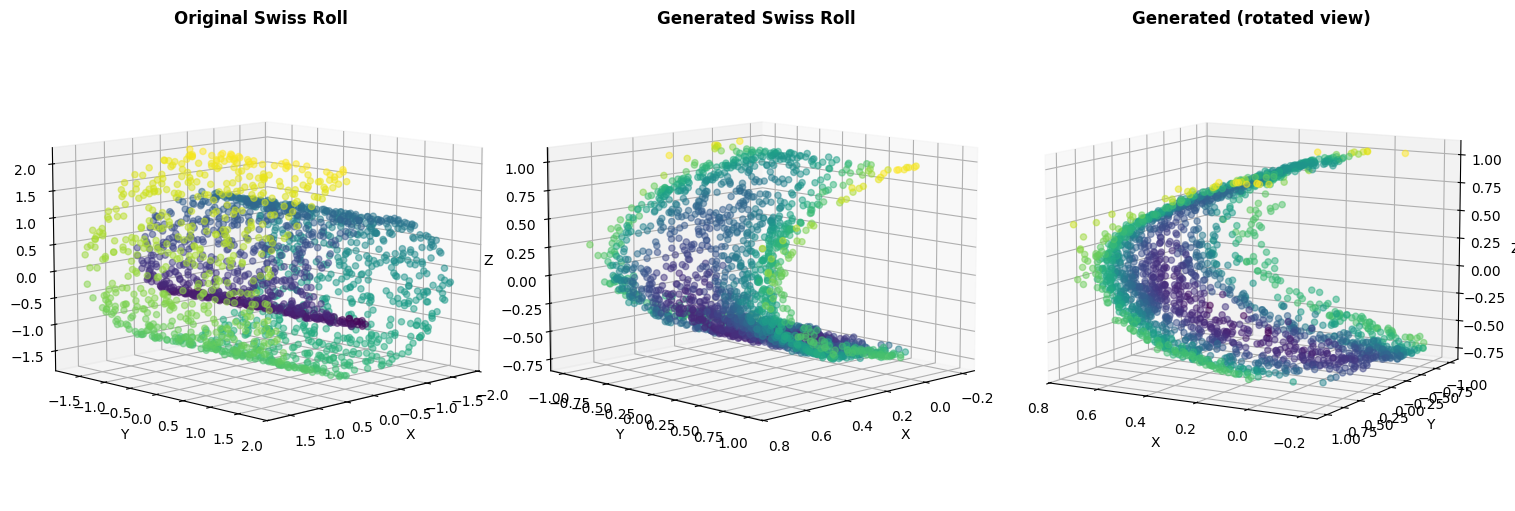

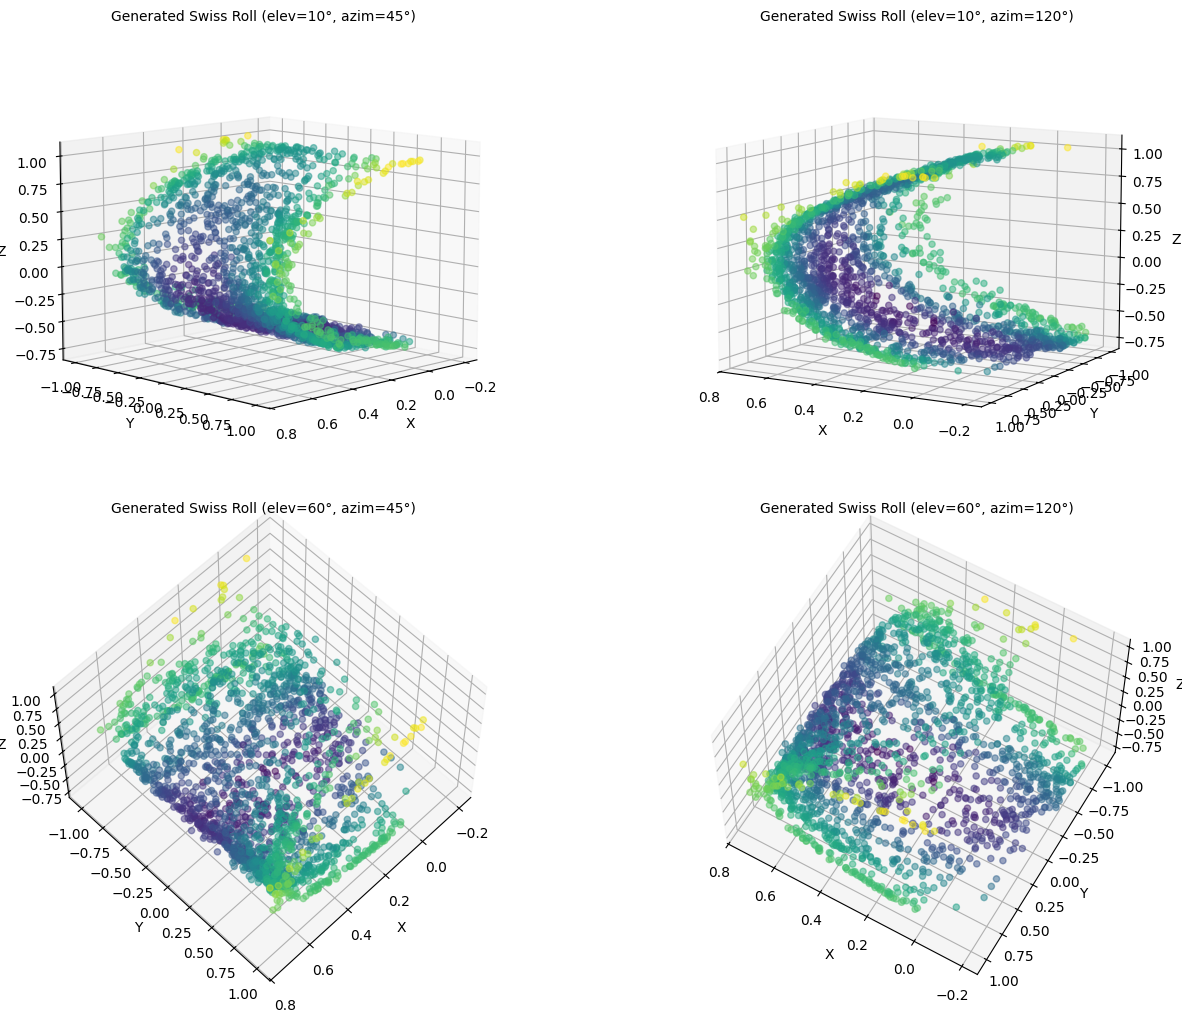

In [9]:
generator.eval()
with torch.no_grad():
    n_samples = 2000
    z_samples = torch.randn(n_samples, latent_dim, device=device)
    generated_samples = generator(z_samples).cpu().numpy()

print(f"Generated samples shape: {generated_samples.shape}")
print(f"Generated samples statistics - Mean: {generated_samples.mean(axis=0)}, Std: {generated_samples.std(axis=0)}")

fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_normalized[:, 0], X_normalized[:, 1], X_normalized[:, 2], 
            c=t, cmap='viridis', alpha=0.5, s=20)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Original Swiss Roll', fontsize=12, fontweight='bold')
ax1.view_init(elev=10, azim=45)

ax2 = fig.add_subplot(132, projection='3d')
color_scale = np.linalg.norm(generated_samples, axis=1)
scatter = ax2.scatter(generated_samples[:, 0], generated_samples[:, 1], generated_samples[:, 2], 
                      c=color_scale, cmap='viridis', alpha=0.5, s=20)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('Generated Swiss Roll', fontsize=12, fontweight='bold')
ax2.view_init(elev=10, azim=45)

ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(generated_samples[:, 0], generated_samples[:, 1], generated_samples[:, 2], 
            c=color_scale, cmap='viridis', alpha=0.5, s=20)
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.set_title('Generated (rotated view)', fontsize=12, fontweight='bold')
ax3.view_init(elev=10, azim=120)

plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(15, 10))
angles = [(10, 45), (10, 120), (60, 45), (60, 120)]

for idx, (elev, azim) in enumerate(angles, 1):
    ax = fig.add_subplot(2, 2, idx, projection='3d')
    ax.scatter(generated_samples[:, 0], generated_samples[:, 1], generated_samples[:, 2], 
               c=color_scale, cmap='viridis', alpha=0.5, s=20)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Generated Swiss Roll (elev={elev}°, azim={azim}°)', fontsize=10)
    ax.view_init(elev=elev, azim=azim)

plt.tight_layout()
plt.show()

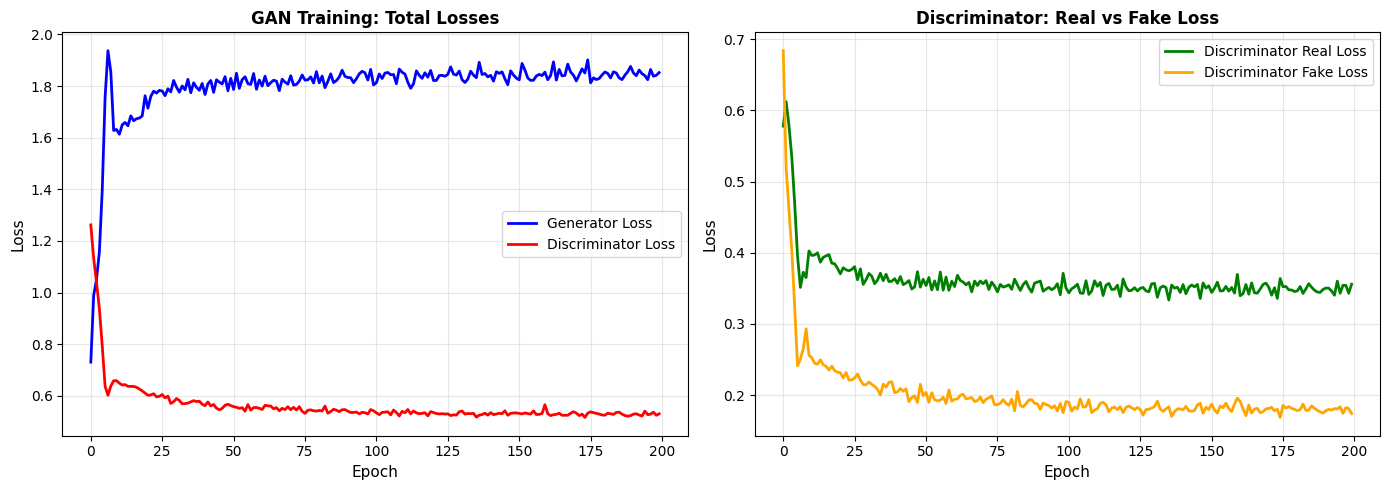

Generator Loss:              1.8523
Discriminator Loss:          0.5300
Discriminator Real Loss:     0.3558
Discriminator Fake Loss:     0.1742

Loss Statistics:
Generator Loss - Min: 0.7304, Max: 1.9372, Mean: 1.8005
Discriminator Loss - Min: 0.5162, Max: 1.2620, Mean: 0.5620

Generated Data Statistics:
Shape: (2000, 3)
Mean: [ 0.37917906  0.09380634 -0.03765006]
Std: [0.24943955 0.6008513  0.54692554]
Min: [-0.19665135 -1.         -0.7277461 ]
Max: [0.7369446 1.        0.9999987]

Original Data Statistics:
Shape: (2000, 3)
Mean: [ 3.37507799e-17 -5.68434189e-17 -3.55271368e-18]
Std: [1. 1. 1.]
Min: [-1.79131032 -1.73491952 -1.61135183]
Max: [1.64383998 1.75557106 2.0341594 ]

Discriminator Confidence Analysis:
Real samples - Mean confidence: 0.8416,Std: 0.3234
Fake samples - Mean confidence: 0.2026,Std: 0.0988


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(g_losses, label='Generator Loss', linewidth=2, color='blue')
axes[0].plot(d_losses, label='Discriminator Loss', linewidth=2, color='red')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('GAN Training: Total Losses', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(d_real_losses, label='Discriminator Real Loss', linewidth=2, color='green')
axes[1].plot(d_fake_losses, label='Discriminator Fake Loss', linewidth=2, color='orange')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].set_title('Discriminator: Real vs Fake Loss', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Generator Loss:              {g_losses[-1]:.4f}")
print(f"Discriminator Loss:          {d_losses[-1]:.4f}")
print(f"Discriminator Real Loss:     {d_real_losses[-1]:.4f}")
print(f"Discriminator Fake Loss:     {d_fake_losses[-1]:.4f}")

print(f"\nLoss Statistics:")
print(f"Generator Loss - Min: {min(g_losses):.4f}, Max: {max(g_losses):.4f}, Mean: {np.mean(g_losses):.4f}")
print(f"Discriminator Loss - Min: {min(d_losses):.4f}, Max: {max(d_losses):.4f}, Mean: {np.mean(d_losses):.4f}")

print(f"\nGenerated Data Statistics:")
print(f"Shape: {generated_samples.shape}")
print(f"Mean: {generated_samples.mean(axis=0)}")
print(f"Std: {generated_samples.std(axis=0)}")
print(f"Min: {generated_samples.min(axis=0)}")
print(f"Max: {generated_samples.max(axis=0)}")

print(f"\nOriginal Data Statistics:")
print(f"Shape: {X_normalized.shape}")
print(f"Mean: {X_normalized.mean(axis=0)}")
print(f"Std: {X_normalized.std(axis=0)}")
print(f"Min: {X_normalized.min(axis=0)}")
print(f"Max: {X_normalized.max(axis=0)}")

print(f"\nDiscriminator Confidence Analysis:")
discriminator.eval()
with torch.no_grad():
    real_confidence = discriminator(X_tensor[:500]).cpu().numpy()
    
    z_test = torch.randn(500, latent_dim, device=device)
    fake_confidence = discriminator(generator(z_test)).cpu().numpy()

print(f"Real samples - Mean confidence: {real_confidence.mean():.4f},Std: {real_confidence.std():.4f}")
print(f"Fake samples - Mean confidence: {fake_confidence.mean():.4f},Std: {fake_confidence.std():.4f}")